In [1]:
import os
from glob import glob
import time

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
from tqdm.auto import tqdm
from matplotlib.ticker import FuncFormatter

from PIL import Image

from scipy.signal import find_peaks

In [2]:
data_path = "../../../Downloads/archive"

In [3]:
data_stats_files = glob(os.path.join(data_path, 'aggregate/*.csv'))
data_deaths_files = glob(os.path.join(data_path, 'deaths/*.csv'))

for file in data_stats_files + data_deaths_files:
    print(os.path.basename(file))

erangel_img = mpimg.imread(os.path.join(data_path, 'erangel.jpg'))
# erangel_img_pil = Image.fromarray((erangel_img * 255).astype(np.uint8))  # Convert to uint8 and to a PIL Image
# erangel_img_resized = erangel_img_pil.resize((1024, 1024))  # Resize to 1024x1024
# erangel_img = np.array(erangel_img_resized)

erangel_img_pil = Image.open(os.path.join(data_path, 'erangel.jpg'))
erangel_img_resized = erangel_img_pil.resize((256, 256))  # Resize to 1024x1024
erangel_img = np.array(erangel_img_resized)

agg_match_stats_0.csv
agg_match_stats_1.csv
agg_match_stats_2.csv
agg_match_stats_3.csv
agg_match_stats_4.csv
kill_match_stats_final_0.csv
kill_match_stats_final_1.csv
kill_match_stats_final_2.csv
kill_match_stats_final_3.csv
kill_match_stats_final_4.csv


In [4]:
start_time = time.perf_counter()

df = pd.read_csv(data_stats_files[0])

end_time = time.perf_counter()
print(f"Time taken to read the agg_match_stats file: {end_time - start_time:.6f} seconds")

Time taken to read the agg_match_stats file: 25.502558 seconds


In [5]:
start_time = time.perf_counter()

death_df = pd.read_csv(data_deaths_files[0])

end_time = time.perf_counter()
print(f"Time taken to read the kill_match_stats file: {end_time - start_time:.6f} seconds")

Time taken to read the kill_match_stats file: 24.468992 seconds


In [6]:
print(df.head(5))
print(f"Number of rows and columns: {df.shape}")
df = df.dropna()
print(f"Number of rows and columns after dropna: {df.shape}")

                       date  game_size  \
0  2017-11-26T20:59:40+0000         37   
1  2017-11-26T20:59:40+0000         37   
2  2017-11-26T20:59:40+0000         37   
3  2017-11-26T20:59:40+0000         37   
4  2017-11-26T20:59:40+0000         37   

                                            match_id match_mode  party_size  \
0  2U4GBNA0YmnNZYkzjkfgN4ev-hXSrak_BSey_YEG6kIuDG...        tpp           2   
1  2U4GBNA0YmnNZYkzjkfgN4ev-hXSrak_BSey_YEG6kIuDG...        tpp           2   
2  2U4GBNA0YmnNZYkzjkfgN4ev-hXSrak_BSey_YEG6kIuDG...        tpp           2   
3  2U4GBNA0YmnNZYkzjkfgN4ev-hXSrak_BSey_YEG6kIuDG...        tpp           2   
4  2U4GBNA0YmnNZYkzjkfgN4ev-hXSrak_BSey_YEG6kIuDG...        tpp           2   

   player_assists  player_dbno  player_dist_ride  player_dist_walk  \
0               0            1        2870.72400       1784.847780   
1               0            1        2938.40723       1756.079710   
2               0            0           0.00000        224.15

In [36]:
print("Preview of DataFrame:")
print(death_df.head(5))

print(f"Before dropna: {death_df.shape[0]} rows, {death_df.shape[1]} columns")

death_df = death_df.dropna()

print(f"After dropna: {death_df.shape[0]} rows, {death_df.shape[1]} columns")

death_df = death_df[~((death_df['victim_position_x'] == 0.0) & (death_df['victim_position_y'] == 0.0))]

death_df = death_df[~((death_df['killer_position_x'] == 0.0) & (death_df['killer_position_y'] == 0.0))]

print(f"After removing (0.0, 0.0) victim positions: {death_df.shape[0]} rows, {death_df.shape[1]} columns")

Preview of DataFrame:
      killed_by       killer_name  killer_placement  killer_position_x  \
0       Grenade   KrazyPortuguese               5.0          657725.10   
1        SCAR-L  nide2Bxiaojiejie              31.0           93091.37   
2          S686          Ascholes              43.0          366921.40   
3  Down and Out        Weirdo7777               9.0          472014.20   
4          M416         Solayuki1               9.0          473357.80   

   killer_position_y      map  \
0           146275.2  MIRAMAR   
1           722236.4  MIRAMAR   
2           421623.9  MIRAMAR   
3           313274.8  MIRAMAR   
4           318340.5  MIRAMAR   

                                            match_id  time      victim_name  \
0  2U4GBNA0YmnLSqvEycnTjo-KT000vfUnhSA2vfVhVPe1QB...   823  KrazyPortuguese   
1  2U4GBNA0YmnLSqvEycnTjo-KT000vfUnhSA2vfVhVPe1QB...   194      X3evolution   
2  2U4GBNA0YmnLSqvEycnTjo-KT000vfUnhSA2vfVhVPe1QB...   103          CtrlZee   
3  2U4GBNA0YmnLSqv

In [37]:
maps = death_df['map'].unique()
print(f"Unique map values: {maps}")

Unique map values: ['MIRAMAR' 'ERANGEL']


In [38]:
erangel_death_df = death_df[death_df['map'] == 'ERANGEL']

In [39]:
max_time = erangel_death_df['time'].max()
min_time = erangel_death_df['time'].min()

print(f"Maximum time: {max_time}")
print(f"Minimum time: {min_time}")

Maximum time: 2374
Minimum time: 28


In [40]:
unique_match_ids = df['match_id'].unique()
print(f"Number of unique match_id values: {len(unique_match_ids)}")

death_unique_match_ids = erangel_death_df['match_id'].unique()
print(f"Number of ERANGEL unique match_id values: {len(death_unique_match_ids)}")

valid_match_ids = np.intersect1d(unique_match_ids, death_unique_match_ids)
print(f"Valid match_ids: {len(valid_match_ids)}")

Number of unique match_id values: 149994
Number of ERANGEL unique match_id values: 118838
Valid match_ids: 118835


In [41]:
# for i, match_id in enumerate(valid_match_ids):
    
#     print(i, match_id)
    
#     # filtered_df = df[df['match_id'] == match_id]
#     # print(f"Number of rows for match_id {match_id}: {filtered_df.shape[0]}")

#     filtered_df = erangel_death_df[erangel_death_df['match_id'] == match_id]
#     print(f"Number of rows for match_id {match_id}: {filtered_df.shape[0]}")

#     center_x = np.mean(filtered_df['victim_position_x'])
#     center_y = np.mean(filtered_df['victim_position_y'])

#     last_row = filtered_df.loc[filtered_df['time'].idxmax()]
#     last_position_x = last_row['victim_position_x']
#     last_position_y = last_row['victim_position_y']

#     plt.figure(figsize=(8, 6))

#     plt.scatter(filtered_df['victim_position_x'], filtered_df['victim_position_y'], 
#                 c=filtered_df['time'],
#                 alpha=0.5)
    
#     plt.xlabel('Victim Position X')
#     plt.ylabel('Victim Position Y')
#     plt.title('Scatter Plot of Victim Positions')

#     circle_radius = 50000  # 반지름 설정 (원하는 크기로 조정 가능)
#     # circle = Circle((center_x, center_y), circle_radius, color='r', fill=False, linestyle='--', linewidth=2)
#     circle = Circle((last_position_x, last_position_y), circle_radius, color='r', fill=False, linestyle='--', linewidth=2)
#     plt.gca().add_patch(circle)
    
#     plt.axis('equal')
#     plt.colorbar()
    
#     plt.show()

#     print()
    
#     if (i == 2): break

0 2U4GBNA0Ymk--3atnvB2Cy2-kmfWLqeLwaiFMfmzWQFhCkWmYZiq4XKDsLngboSq
Number of rows for match_id 2U4GBNA0Ymk--3atnvB2Cy2-kmfWLqeLwaiFMfmzWQFhCkWmYZiq4XKDsLngboSq: 81


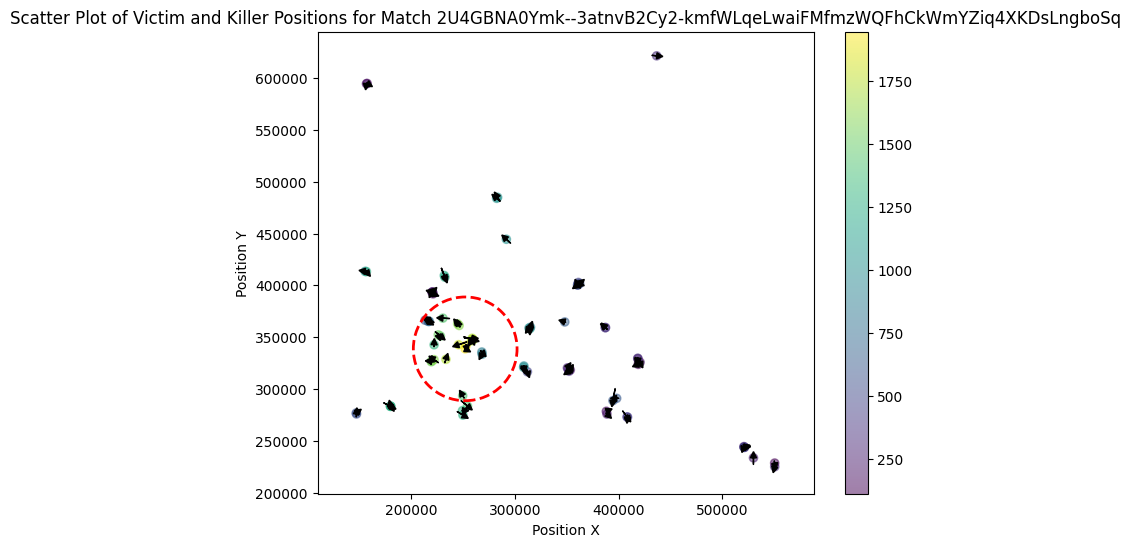


1 2U4GBNA0Ymk--3eiHoaWZvPpeDFMZNYSMM6AOtbUTMCM85nnoNrjNVLzIPDXtHsh
Number of rows for match_id 2U4GBNA0Ymk--3eiHoaWZvPpeDFMZNYSMM6AOtbUTMCM85nnoNrjNVLzIPDXtHsh: 83


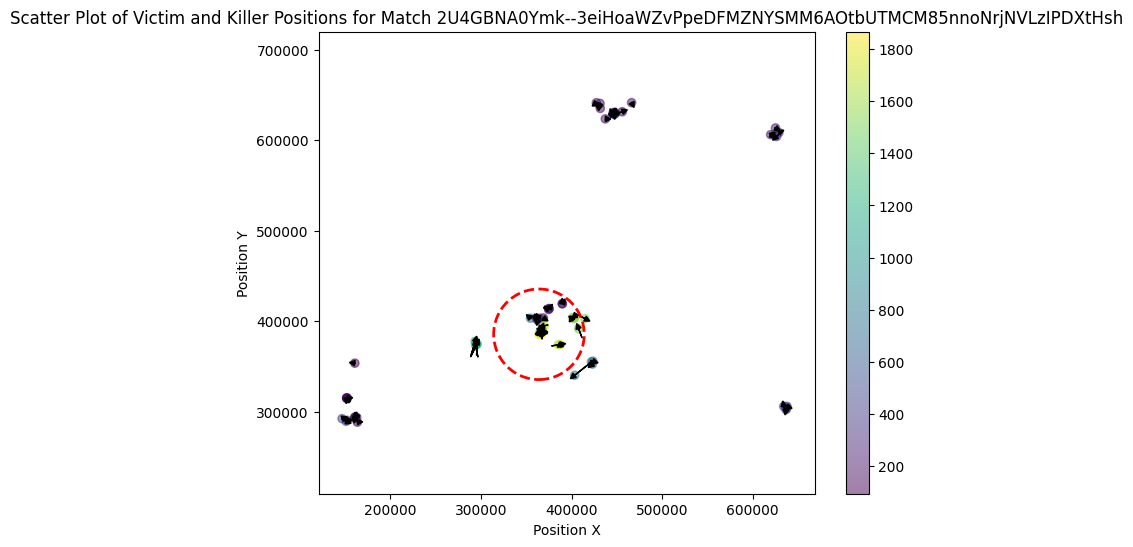


2 2U4GBNA0Ymk--IzbW-ihltP44UHbUvm7oAku86yTg7UOs4oWhJhsnTMzjwRkf72n
Number of rows for match_id 2U4GBNA0Ymk--IzbW-ihltP44UHbUvm7oAku86yTg7UOs4oWhJhsnTMzjwRkf72n: 82


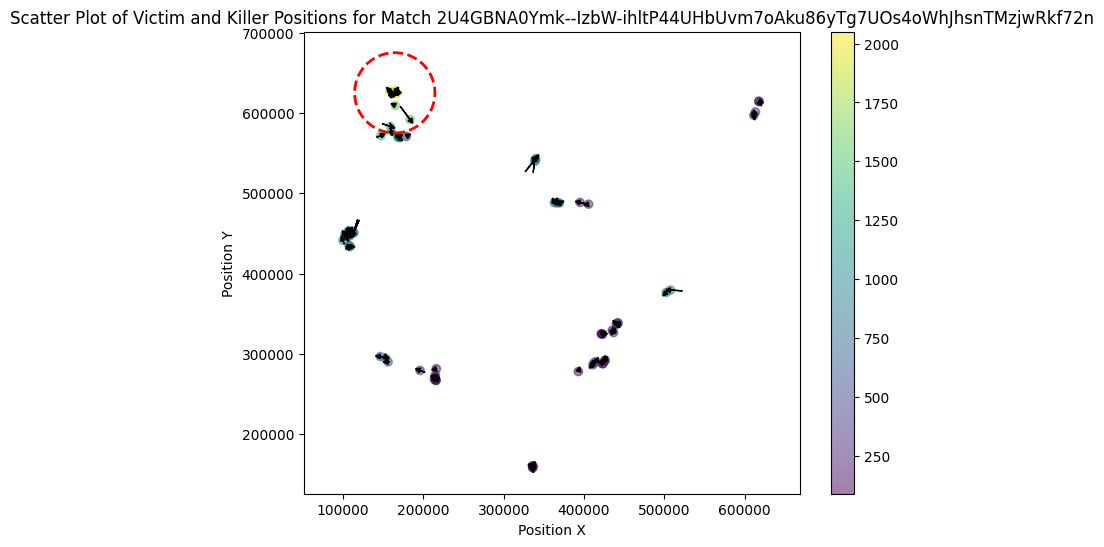

In [43]:
for i, match_id in enumerate(valid_match_ids):
    
    print(i, match_id)
    
    # 필터링된 데이터프레임 생성
    filtered_df = erangel_death_df[erangel_death_df['match_id'] == match_id]
    print(f"Number of rows for match_id {match_id}: {filtered_df.shape[0]}")

    center_x = np.mean(filtered_df['victim_position_x'])
    center_y = np.mean(filtered_df['victim_position_y'])

    last_row = filtered_df.loc[filtered_df['time'].idxmax()]
    last_position_x = last_row['victim_position_x']
    last_position_y = last_row['victim_position_y']

    plt.figure(figsize=(8, 6))

    # 피해자 위치의 산점도 그리기
    plt.scatter(filtered_df['victim_position_x'], filtered_df['victim_position_y'], 
                c=filtered_df['time'],
                alpha=0.5)

    # 킬러와 피해자 사이의 화살표 그리기
    for _, row in filtered_df.iterrows():
        killer_x = row['killer_position_x']
        killer_y = row['killer_position_y']
        victim_x = row['victim_position_x']
        victim_y = row['victim_position_y']
        
        # 킬러와 피해자의 위치를 연결하는 화살표
        plt.arrow(killer_x, killer_y, victim_x - killer_x, victim_y - killer_y,
                  head_width=6000, head_length=6000, fc='k', ec='k')

    # 차트 설정
    plt.xlabel('Position X')
    plt.ylabel('Position Y')
    plt.title(f'Scatter Plot of Victim and Killer Positions for Match {match_id}')
    
    # 마지막 피해자 위치에 원 추가
    circle_radius = 50000
    circle = Circle((last_position_x, last_position_y), circle_radius, color='r', fill=False, linestyle='--', linewidth=2)
    plt.gca().add_patch(circle)
    
    plt.axis('equal')
    plt.colorbar()
    
    plt.show()

    print()

    # 3번째 매치 이후에 종료
    if i == 2: break

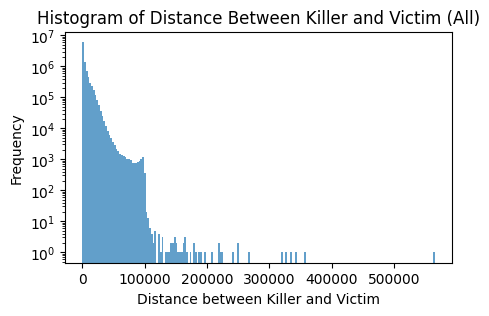

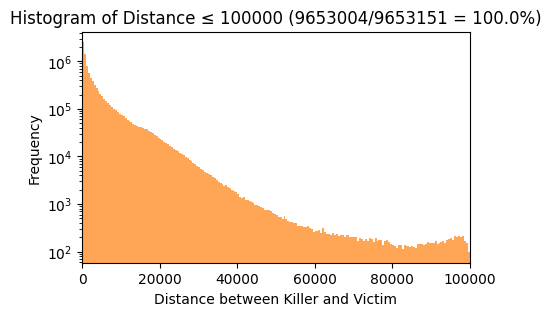

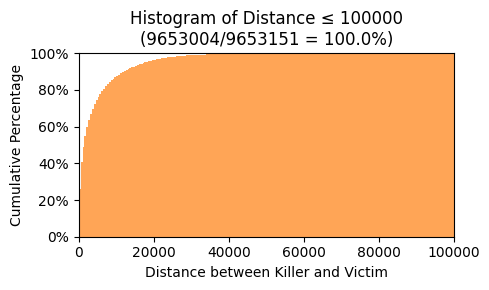

In [60]:
# 거리 계산
distance = np.sqrt(
    (erangel_death_df['killer_position_x'] - erangel_death_df['victim_position_x'])**2 + 
    (erangel_death_df['killer_position_y'] - erangel_death_df['victim_position_y'])**2
)

# 전체 거리 히스토그램
plt.figure(figsize=(5, 3))
plt.hist(distance, bins=200, color='tab:blue', alpha=0.7, log=True)
plt.xlabel('Distance between Killer and Victim')
plt.ylabel('Frequency')
plt.title('Histogram of Distance Between Killer and Victim (All)')
plt.show()

# 거리 100000 이하 필터링
distance_within_100000 = distance[distance <= 100000]

# 제한된 거리 히스토그램
plt.figure(figsize=(5, 3))
plt.hist(distance_within_100000, bins=200, color='tab:orange', alpha=0.7, log=True)
plt.xlabel('Distance between Killer and Victim')
plt.ylabel('Frequency')
plt.title(f'Histogram of Distance ≤ 100000 ({len(distance_within_100000)}/{len(distance)} = {(len(distance_within_100000)/len(distance))*100:.1f}%)')
plt.xlim(0, 100000)
plt.show()

plt.figure(figsize=(5, 3))

plt.hist(
    distance_within_100000,
    bins=200,
    color='tab:orange',
    alpha=0.7,
    cumulative=True,
    density=True
)

# Y축을 퍼센티지로 변환
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

plt.xlabel('Distance between Killer and Victim')
plt.ylabel('Cumulative Percentage')
plt.title(f'Histogram of Distance ≤ 100000\n({len(distance_within_100000)}/{len(distance)} = {(len(distance_within_100000)/len(distance))*100:.1f}%)')
plt.xlim(0, 100000)
plt.ylim(0, 1)  # 누적 밀도니까 최대 1.0

plt.tight_layout()
plt.show()

In [80]:
# # 시간 구간 설정 (0부터 최대 time까지 50초 간격)
# time_min = erangel_death_df['time'].min()
# time_max = erangel_death_df['time'].max()
# time_bins = np.arange(0, time_max + 50, 50)

# # 각 시간 구간별로 처리
# for i in range(len(time_bins) - 1):
#     start_time = time_bins[i]
#     end_time = time_bins[i + 1]

#     # 해당 구간에 속하는 데이터 필터링
#     time_filtered_df = erangel_death_df[
#         (erangel_death_df['time'] >= start_time) &
#         (erangel_death_df['time'] < end_time)
#     ]

#     # 거리 계산
#     distance = np.sqrt(
#         (time_filtered_df['killer_position_x'] - time_filtered_df['victim_position_x'])**2 +
#         (time_filtered_df['killer_position_y'] - time_filtered_df['victim_position_y'])**2
#     )

#     # 거리 100000 이하만 사용
#     distance_within = distance[distance <= 100000]

#     # 히스토그램 플롯
#     plt.figure(figsize=(5, 3))
#     plt.hist(distance_within, bins=100, color='tab:purple', alpha=0.7, log=True)
#     plt.xlabel('Distance between Killer and Victim')
#     plt.ylabel('Frequency')
#     plt.title(f'Distance ≤ 100000 (Time: {start_time}–{end_time}s, N={len(distance_within)})')
#     plt.xlim(0, 100000)
#     plt.tight_layout()
#     plt.show()

In [61]:
# # 'death'가 포함된 killed_by 항목을 제외하고 그룹화
# filtered_df = erangel_death_df[~erangel_death_df['killed_by'].str.contains('death', case=False, na=False)]

# # killed_by 항목별로 거리 계산 후 별도의 Figure로 히스토그램 그리기
# for killed_by_type, group in filtered_df.groupby('killed_by'):
#     # 킬러와 피해자 사이의 거리 계산
#     distance = np.sqrt(
#         (group['killer_position_x'] - group['victim_position_x'])**2 + 
#         (group['killer_position_y'] - group['victim_position_y'])**2
#     )
    
#     # 새로운 Figure 생성
#     plt.figure(figsize=(5, 3))
    
#     # 거리의 히스토그램
#     plt.hist(distance, bins=50, alpha=0.7, color='tab:blue', log=True)

#     # 히스토그램에 관련된 설정
#     plt.xlabel('Distance between Killer and Victim')
#     plt.ylabel('Frequency')
#     plt.title(f'Histogram of Distance Between Killer and Victim for {killed_by_type}')

#     # 그래프 표시
#     plt.show()

In [84]:
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# %matplotlib notebook

# # 시간 구간 설정
# time_min = erangel_death_df['time'].min()
# time_max = erangel_death_df['time'].max()
# time_bins = np.arange(0, time_max + 50, 50)

# # 거리 100000 이하로 필터링된 전체 거리 배열을 미리 준비
# distance_by_time = []

# for i in range(len(time_bins) - 1):
#     start_time = time_bins[i]
#     end_time = time_bins[i + 1]

#     time_filtered_df = erangel_death_df[
#         (erangel_death_df['time'] >= start_time) &
#         (erangel_death_df['time'] < end_time)
#     ]

#     distance = np.sqrt(
#         (time_filtered_df['killer_position_x'] - time_filtered_df['victim_position_x'])**2 +
#         (time_filtered_df['killer_position_y'] - time_filtered_df['victim_position_y'])**2
#     )

#     distance_within = distance[distance <= 100000]
#     distance_by_time.append((start_time, end_time, distance_within))

# # 애니메이션 준비
# fig, ax = plt.subplots(figsize=(6, 4))

# def update(frame_idx):
#     ax.clear()
#     start_time, end_time, distance = distance_by_time[frame_idx]
#     ax.hist(distance, bins=100, color='tab:purple', alpha=0.7, log=True)
#     ax.set_xlim(0, 100000)
#     ax.set_xlabel('Distance between Killer and Victim')
#     ax.set_ylabel('Frequency')
#     ax.set_title(f'Distance ≤ 100000\nTime: {start_time}–{end_time}s (N={len(distance)})')
#     ax.grid(True)

# # 애니메이션 생성
# ani = FuncAnimation(fig, update, frames=len(distance_by_time), interval=500)

# HTML(ani.to_jshtml())

In [62]:
# filtered_df = erangel_death_df[~erangel_death_df['killed_by'].str.contains('death', case=False, na=False)]

# # killed_by 항목별로 거리 계산 후 별도의 Figure로 히스토그램 그리기
# for killed_by_type, group in filtered_df.groupby('killed_by'):
#     # 킬러와 피해자 사이의 거리 계산
#     distance = np.sqrt(
#         (group['killer_position_x'] - group['victim_position_x'])**2 + 
#         (group['killer_position_y'] - group['victim_position_y'])**2
#     )

#     # 최대 거리 100000 이하인 값들의 비율 계산
#     within_limit = distance[distance <= 100000]
#     total_count = len(distance)
#     within_count = len(within_limit)
#     ratio = (within_count / total_count) * 100

#     # 새로운 Figure 생성
#     plt.figure(figsize=(5, 3))

#     # 거리의 히스토그램 (100000 이하의 값만 사용, x축은 최대 100000으로 제한)
#     plt.hist(within_limit, bins=50, alpha=0.7, color='tab:blue', log=True)

#     # 히스토그램에 관련된 설정
#     plt.xlabel('Distance between Killer and Victim')
#     plt.ylabel('Frequency')
#     plt.title(f'{killed_by_type} ({within_count}/{total_count} = {ratio:.1f}%)')
#     plt.xlim(0, 100000)

#     # 그래프 표시
#     plt.show()

In [63]:
match_id = valid_match_ids[0]
    
filtered_df = erangel_death_df[erangel_death_df['match_id'] == match_id]
print(f"Number of rows for match_id {match_id}: {filtered_df.shape[0]}")


Number of rows for match_id 2U4GBNA0Ymk--3atnvB2Cy2-kmfWLqeLwaiFMfmzWQFhCkWmYZiq4XKDsLngboSq: 81


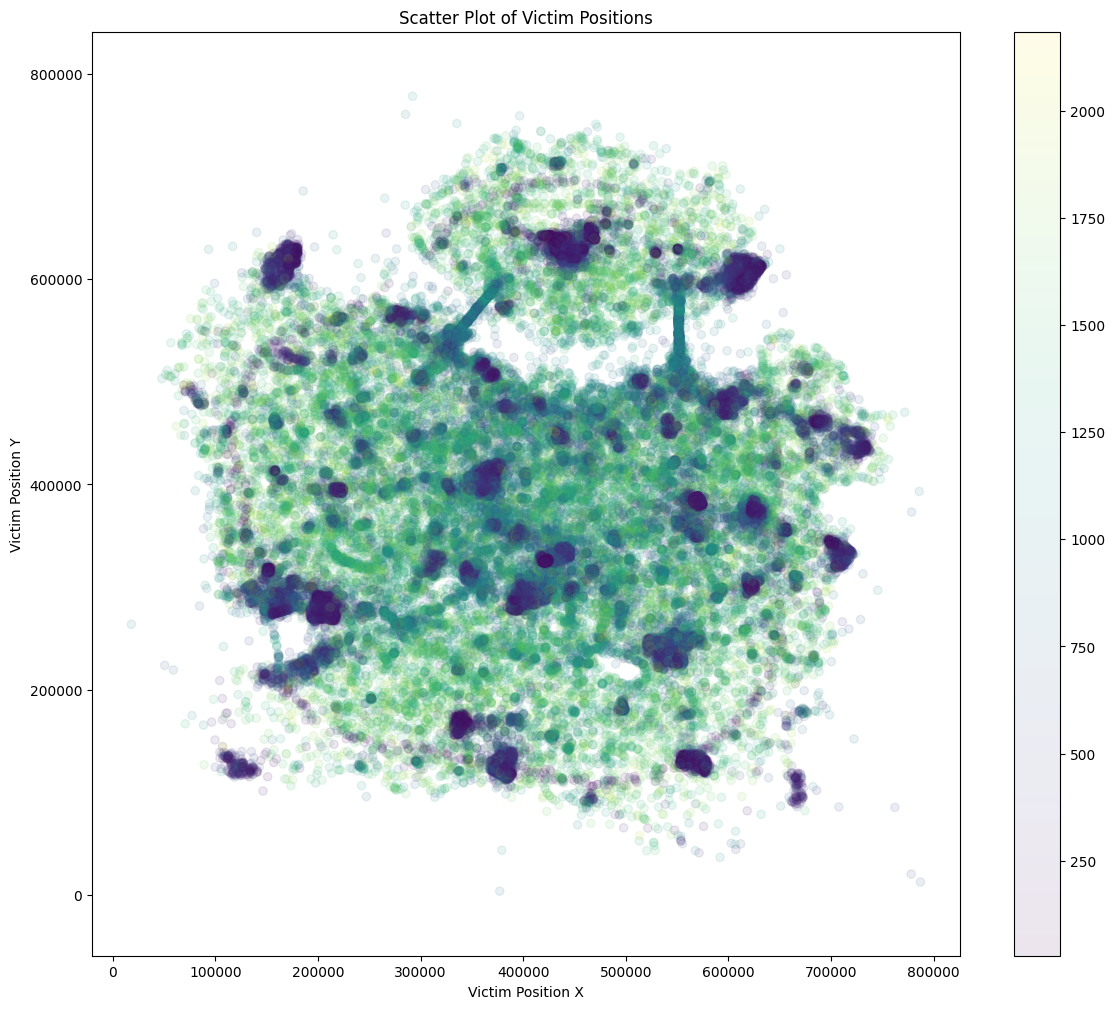

In [65]:
sampled_df = erangel_death_df.sample(frac=0.01, random_state=42)  # 1% of the data, can adjust frac

# Plotting
plt.figure(figsize=(14, 12))

plt.scatter(sampled_df['victim_position_x'], sampled_df['victim_position_y'], 
            c=sampled_df['time'],
            alpha=0.1)

plt.xlabel('Victim Position X')
plt.ylabel('Victim Position Y')
plt.title('Scatter Plot of Victim Positions')

plt.axis('equal')
plt.colorbar()

plt.show()

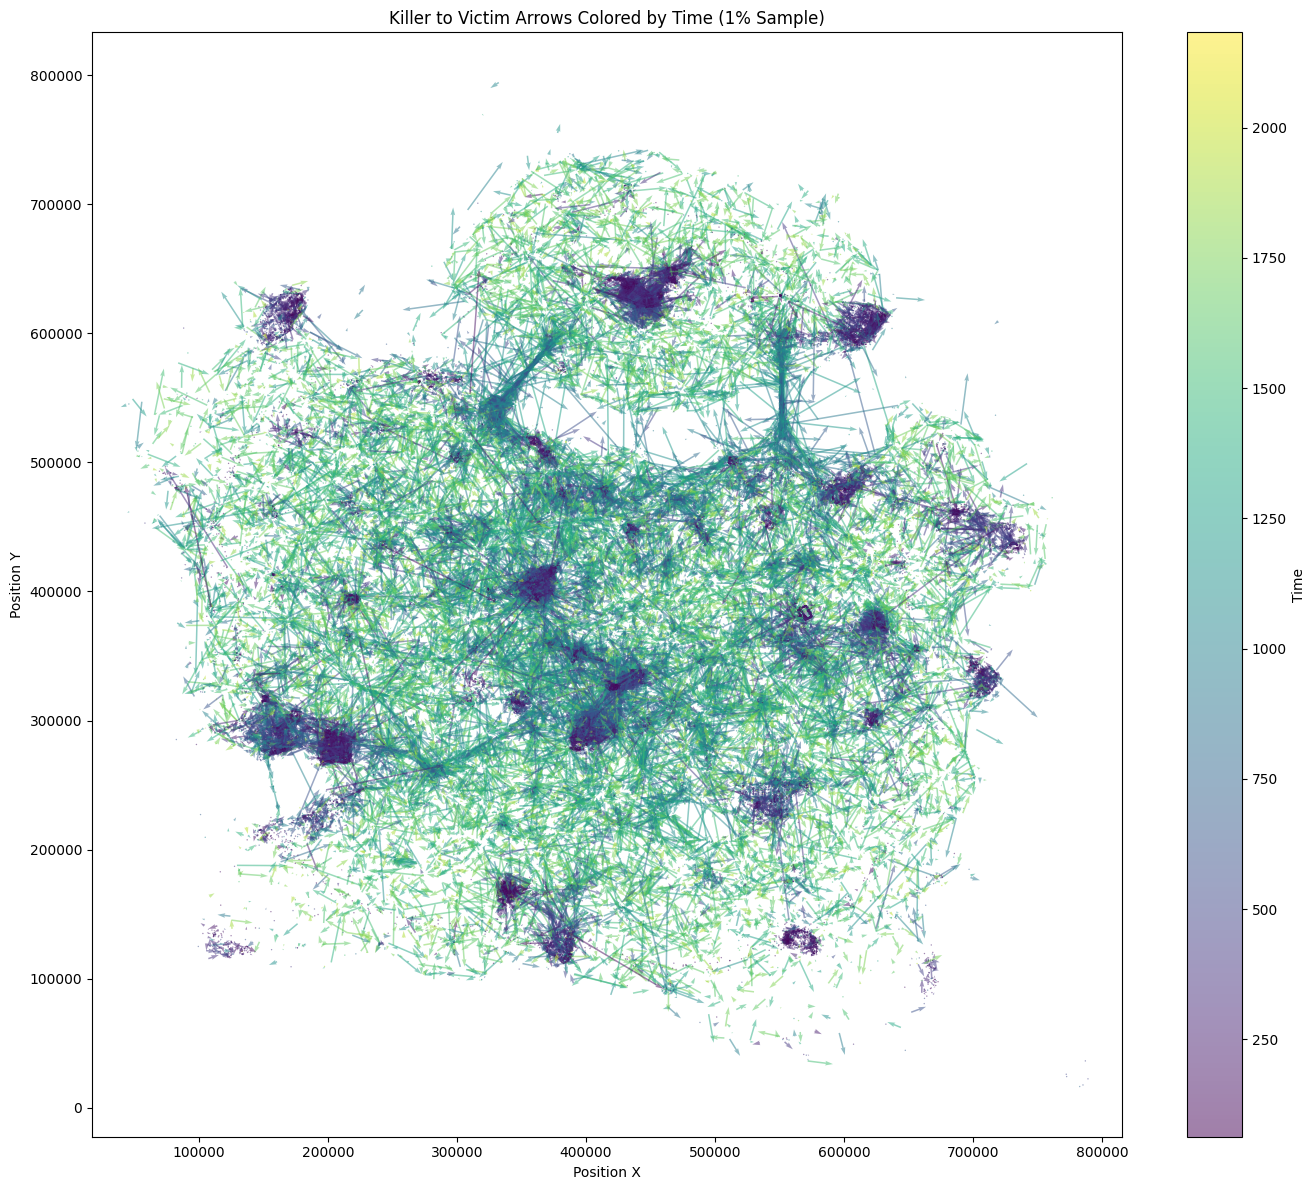

In [70]:
# 거리 계산
distance = np.sqrt(
    (erangel_death_df['killer_position_x'] - erangel_death_df['victim_position_x'])**2 + 
    (erangel_death_df['killer_position_y'] - erangel_death_df['victim_position_y'])**2
)

# 거리 100000 이하인 데이터만 필터링
filtered_df = erangel_death_df[distance <= 100000]

# 1% 샘플링
sampled_df = filtered_df.sample(frac=0.01, random_state=40)

# Plotting
plt.figure(figsize=(14, 12))

# 화살표 벡터 계산: victim - killer
dx = sampled_df['victim_position_x'] - sampled_df['killer_position_x']
dy = sampled_df['victim_position_y'] - sampled_df['killer_position_y']

# time 값을 색상으로 사용
quiver = plt.quiver(
    sampled_df['killer_position_x'], sampled_df['killer_position_y'],  # 시작점
    dx, dy,  # 방향 벡터
    sampled_df['time'],  # 색상에 사용할 값
    angles='xy', scale_units='xy', scale=1, width=0.0015, cmap='viridis', alpha=0.5
)

plt.xlabel('Position X')
plt.ylabel('Position Y')
plt.title('Killer to Victim Arrows Colored by Time (1% Sample)')

plt.axis('equal')
plt.colorbar(quiver, label='Time')
plt.tight_layout()
plt.show()

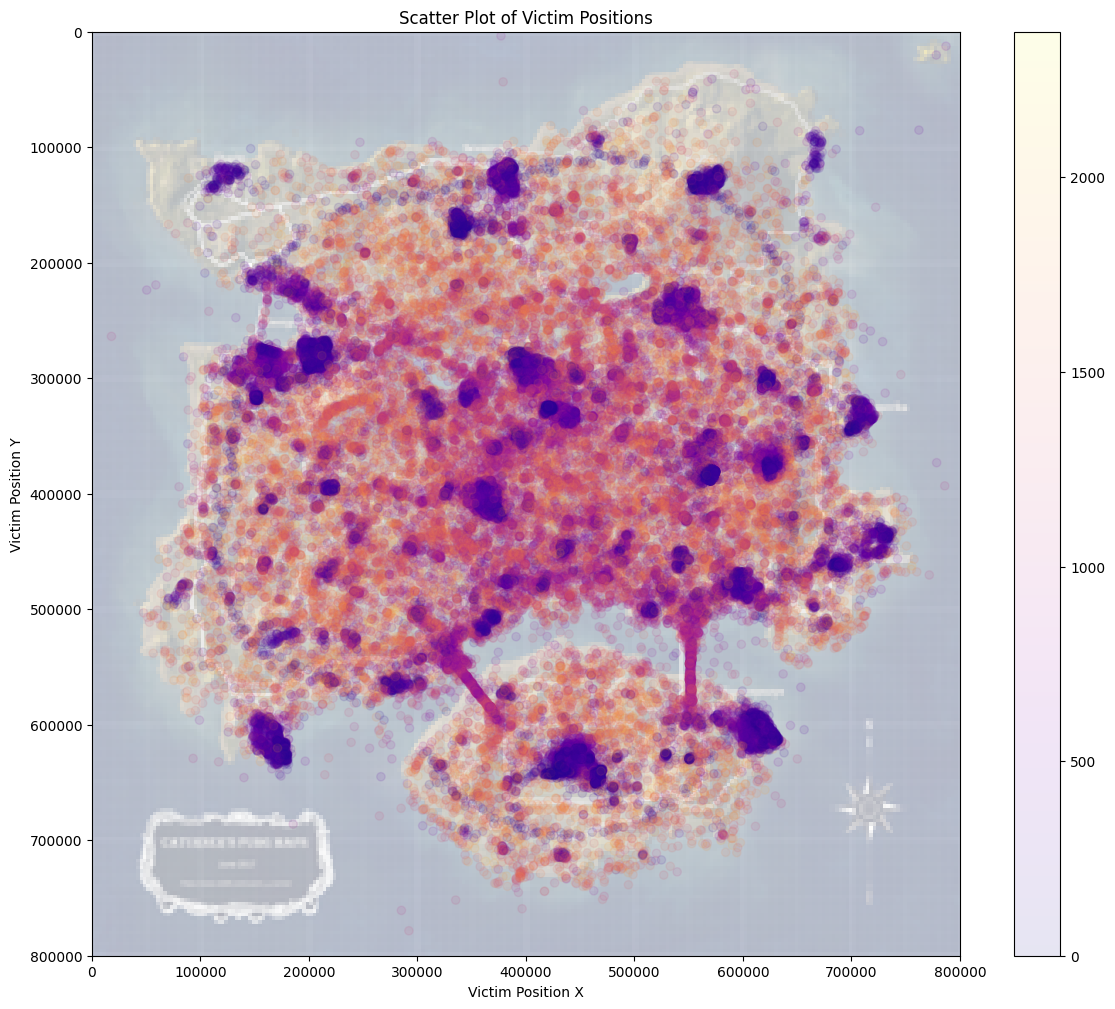

In [71]:
sampled_df = erangel_death_df.sample(frac=0.01, random_state=42)  # 1% of the data, can adjust frac

# Plotting
plt.figure(figsize=(14, 12))

plt.imshow(erangel_img, aspect='auto', extent=[0, 800000, 
                                       800000, 0], alpha=0.3)

plt.scatter(sampled_df['victim_position_x'], sampled_df['victim_position_y'], 
            c=sampled_df['time'],
            # cmap='YlOrRd',
            cmap='plasma',
            alpha=0.1,
            norm=mcolors.Normalize(vmin=0, vmax=max_time))

plt.xlabel('Victim Position X')
plt.ylabel('Victim Position Y')
plt.title('Scatter Plot of Victim Positions')

plt.xlim(0, 800000)
plt.ylim(0, 800000)

plt.gca().invert_yaxis()
# plt.axis('equal')
plt.axis('auto')
plt.colorbar()

plt.show()

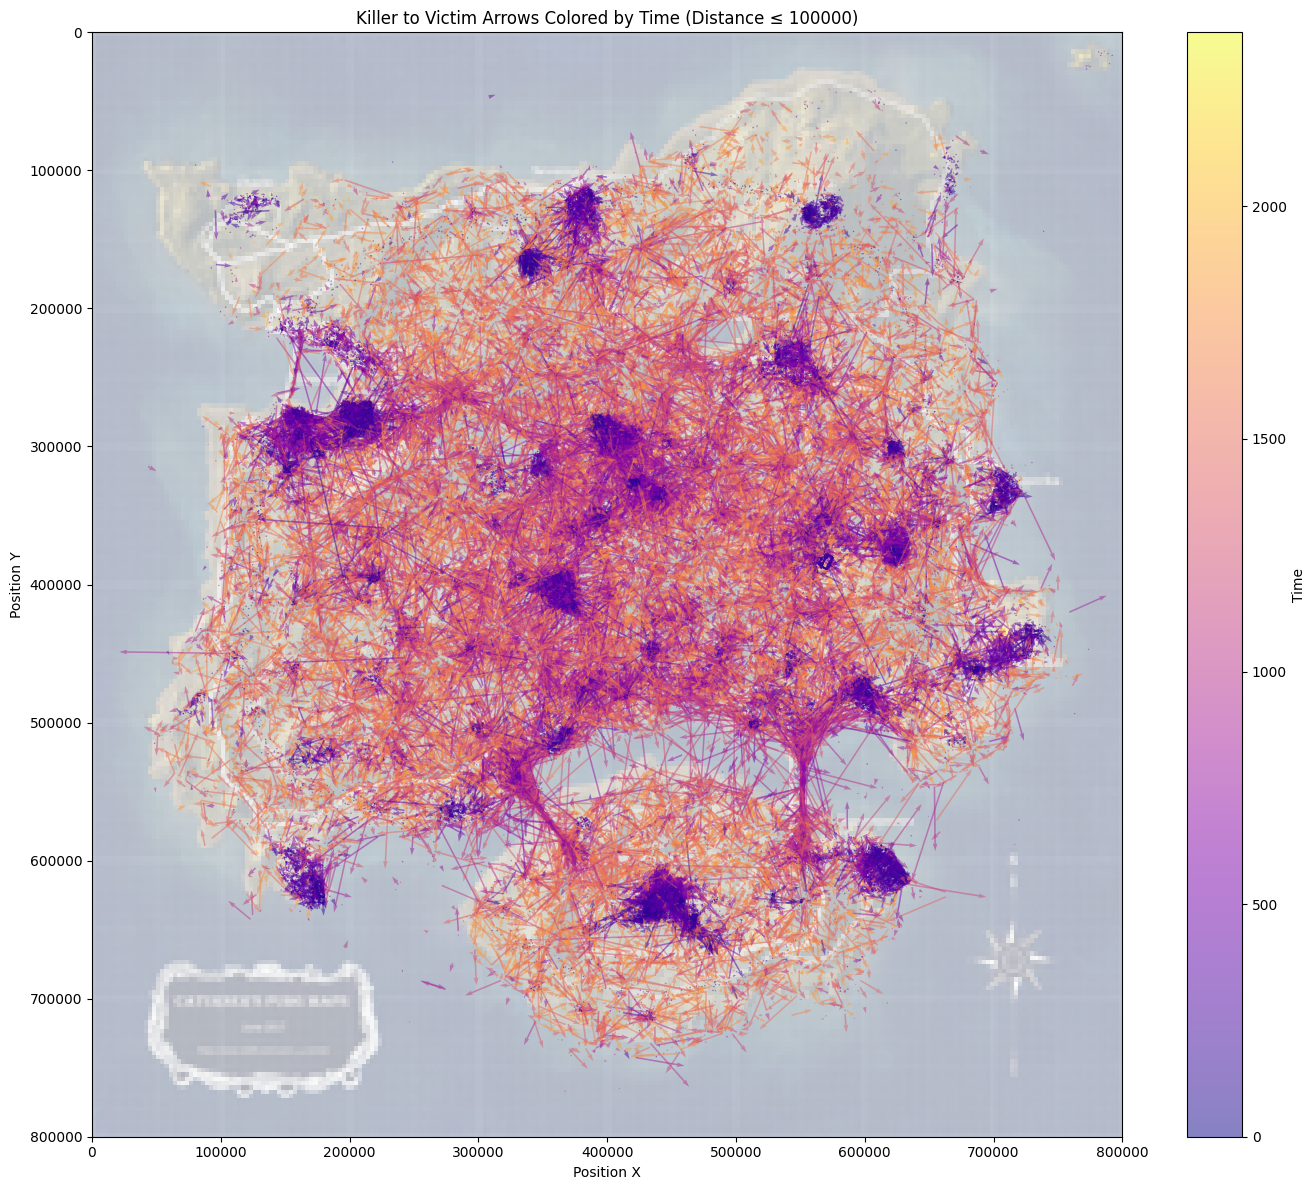

In [76]:
# 거리 계산
distance = np.sqrt(
    (erangel_death_df['killer_position_x'] - erangel_death_df['victim_position_x'])**2 + 
    (erangel_death_df['killer_position_y'] - erangel_death_df['victim_position_y'])**2
)

# 100000 이하의 거리만 필터링
filtered_df = erangel_death_df[distance <= 100000].copy()

# 최대 시간 값 계산 (정규화를 위해)
max_time = filtered_df['time'].max()

# 1% 샘플링
sampled_df = filtered_df.sample(frac=0.015, random_state=42)

# 화살표 방향 벡터 계산
dx = sampled_df['victim_position_x'] - sampled_df['killer_position_x']
dy = sampled_df['victim_position_y'] - sampled_df['killer_position_y']

# 플롯 시작
plt.figure(figsize=(14, 12))

# 배경 이미지
plt.imshow(erangel_img, aspect='auto', extent=[0, 800000, 800000, 0], alpha=0.3)

# 화살표 플롯 (킬러 → 피해자, 색은 time 기준)
quiver = plt.quiver(
    sampled_df['killer_position_x'], sampled_df['killer_position_y'],
    dx, dy,
    sampled_df['time'],
    cmap='plasma',
    norm=mcolors.Normalize(vmin=0, vmax=max_time),
    angles='xy', scale_units='xy', scale=1,
    width=0.0015, alpha=0.5
)

# 라벨 및 설정
plt.xlabel('Position X')
plt.ylabel('Position Y')
plt.title('Killer to Victim Arrows Colored by Time (Distance ≤ 100000)')

plt.xlim(0, 800000)
plt.ylim(0, 800000)
plt.gca().invert_yaxis()
plt.axis('auto')

plt.colorbar(quiver, label='Time')
plt.tight_layout()
plt.show()

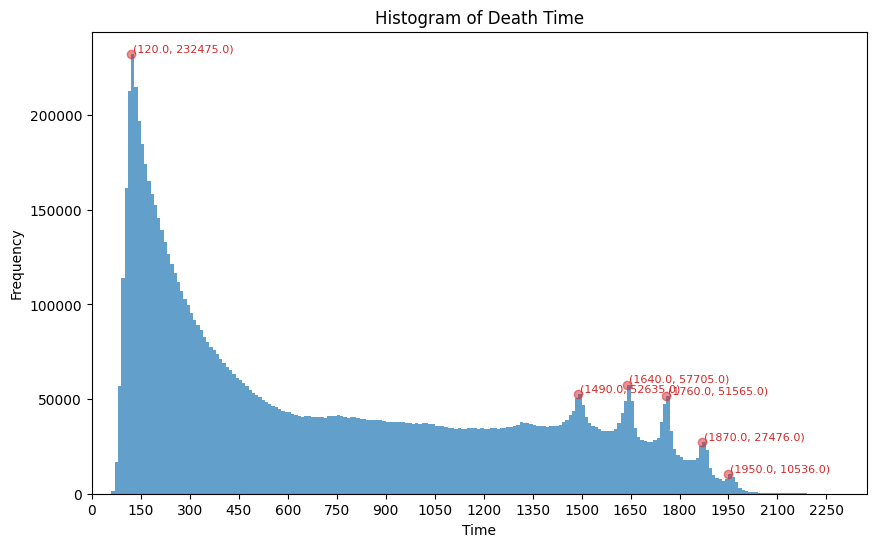

In [55]:
data = erangel_death_df['time']

plt.figure(figsize=(10, 6))

bins = list(range(0, max_time + 10, 10))
# bins = list(range(0, max_time + 1, 1))
counts, bins, patches = plt.hist(data, bins=bins, color='tab:blue', alpha=0.7)

peaks, _ = find_peaks(counts, threshold=1000)

plt.plot(bins[peaks], counts[peaks], "o", color='tab:red', alpha=0.5)

for peak in peaks:
    plt.text(bins[peak] + 5, counts[peak] + 100, f'({bins[peak]}, {counts[peak]})', 
             color='tab:red', ha='left', va='bottom', fontsize=8)

plt.xlabel('Time')
plt.ylabel('Frequency')
plt.title('Histogram of Death Time')

plt.xlim(0, max_time)
plt.xticks(range(0, max_time + 1, 150))

plt.show()

In [16]:
def format_ticks(x, pos):
    if x >= 1000:
        return f'{int(x / 1000)}k'
    return str(int(x))

In [ ]:
output_dir = "scatter_plots"

if os.path.exists(output_dir):
    for file_name in os.listdir(output_dir):
        os.remove(os.path.join(output_dir, file_name))
else:
    os.makedirs(output_dir)

# sampled_df = erangel_death_df.sample(frac=0.01, random_state=42)
sampled_df = erangel_death_df.sample(frac=0.01, random_state=42)

time_counts = sampled_df['time'].value_counts()
# max_time_bin = time_counts.idxmax()

for current_time in tqdm(range(min_time, max_time + 1), desc="Generating scatter plots", unit="time"):
    
    # filtered_df = sampled_df[sampled_df['time'] == current_time]
    filtered_df = sampled_df[(sampled_df['time'] >= current_time - 30) & (sampled_df['time'] <= current_time)]

    current_time_data_count = len(filtered_df[filtered_df['time'] == current_time])
    alpha_weight = time_counts.max() / current_time_data_count if current_time_data_count > 0 else 1
    alpha_weight = np.clip(alpha_weight, 1, 10)

    plt.figure(figsize=(7, 6))

    plt.imshow(erangel_img, aspect='auto', extent=[0, 800000, 800000, 0], alpha=0.3)

    if not filtered_df.empty:
        scatter = plt.scatter(filtered_df['victim_position_x'], filtered_df['victim_position_y'], 
                              c=filtered_df['time'], cmap='plasma', 
                              alpha=0.05 * alpha_weight, 
                              norm=mcolors.Normalize(vmin=0, vmax=max_time),
                              s=5)
    else:
        scatter = plt.scatter([], [], c=[], cmap='plasma', alpha=0.05, 
                              norm=mcolors.Normalize(vmin=0, vmax=max_time),
                              s=5)

    plt.xlabel('Victim Position X')
    plt.ylabel('Victim Position Y')
    plt.title(f'Scatter Plot of Victim Positions: Time = {current_time}')

    plt.xlim(0, 800000)
    plt.ylim(0, 800000)

    plt.gca().invert_yaxis()

    plt.axis('auto')

    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_ticks))
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_ticks))

    cbar = plt.colorbar(scatter)
    cbar.set_label('Time')    
    cbar.set_ticks([min_time, max_time])
    cbar.ax.axhline(y=current_time, color='tab:red', linewidth=1, linestyle='-')

    filename = os.path.join(output_dir, f"scatter_plot_{current_time:04d}.png")
    plt.savefig(filename, bbox_inches='tight')

    plt.close()

print(f"Scatter plots saved in the '{output_dir}' directory.")